WEATHER TYPE CLASSIFICATION

The objective of this project is to predict the Weather Type based on atmospheric features using multiple machine learning classification models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r"C:\Users\HP\Downloads\weather_classification_data.csv")
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy


In [4]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [5]:
df.tail()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy
13199,-5.0,38,0.0,92.0,overcast,1015.37,5,Autumn,10.0,mountain,Rainy


In [6]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [8]:
df.dtypes

Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
dtype: object

In [9]:
df.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [10]:
df.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [11]:
x=df.select_dtypes(include=['float','int'])
x.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Atmospheric Pressure', 'UV Index', 'Visibility (km)'],
      dtype='object')

In [12]:
y=df.select_dtypes(include='object')
y.columns

Index(['Cloud Cover', 'Season', 'Location', 'Weather Type'], dtype='object')

In [13]:
y.nunique()

Cloud Cover     4
Season          4
Location        3
Weather Type    4
dtype: int64

Correlation Heatmap

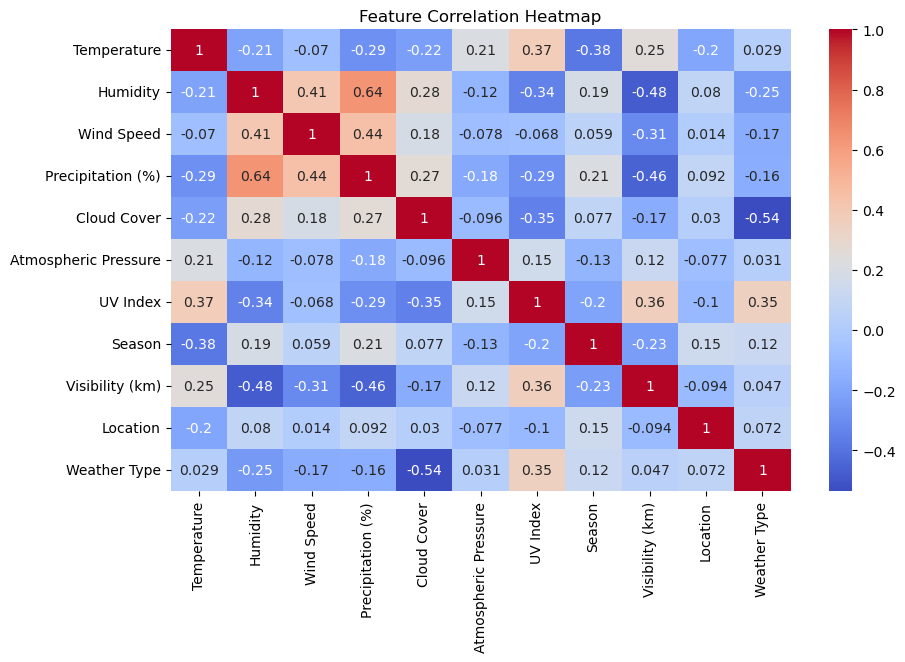

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Data Preprocessing

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [15]:
x=['Cloud Cover', 'Season', 'Location', 'Weather Type']
for i in x:
    df[i]=le.fit_transform(df[i])
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


In [16]:
x=df.drop(['Cloud Cover', 'Season', 'Location', 'Weather Type'],axis=1)

In [17]:
y=df[['Cloud Cover', 'Season', 'Location', 'Weather Type']]
y

,Cloud Cover,Season,Location,Weather Type
0,3,3,1,1
1,3,1,1,0
2,0,1,2,3
3,0,1,0,3
4,2,3,2,1
...,...,...,...,...
13195,2,2,2,1
13196,1,3,0,2
13197,2,0,0,0
13198,2,3,1,2


In [18]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
x2=minmax.fit_transform(x)
x2

array([[0.29104478, 0.59550562, 0.19587629, ..., 0.52795109, 0.14285714,
        0.175     ],
       [0.47761194, 0.85393258, 0.17525773, ..., 0.52947957, 0.5       ,
        0.5       ],
       [0.41044776, 0.49438202, 0.1443299 , ..., 0.54774612, 0.35714286,
        0.275     ],
       ...,
       [0.41044776, 0.64044944, 0.11340206, ..., 0.53263675, 0.21428571,
        0.45      ],
       [0.20895522, 0.62921348, 0.20618557, ..., 0.46142474, 0.        ,
        0.1       ],
       [0.14925373, 0.20224719, 0.        , ..., 0.53935203, 0.35714286,
        0.5       ]])

In [19]:
x2.shape

(13200, 7)

In [20]:
x2=pd.DataFrame(x2,columns=['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Atmospheric Pressure', 'UV Index', 'Visibility (km)'])
x2

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
0,0.291045,0.595506,0.195876,0.752294,0.527951,0.142857,0.175
1,0.477612,0.853933,0.175258,0.651376,0.529480,0.500000,0.500
2,0.410448,0.494382,0.144330,0.146789,0.547746,0.357143,0.275
3,0.470149,0.707865,0.030928,0.752294,0.566614,0.500000,0.050
4,0.388060,0.606742,0.350515,0.605505,0.477461,0.071429,0.125
...,...,...,...,...,...,...,...
13195,0.261194,0.606742,0.298969,0.651376,0.508732,0.071429,0.050
13196,0.179104,0.629213,0.072165,0.211009,0.669298,0.071429,0.300
13197,0.410448,0.640449,0.113402,0.256881,0.532637,0.214286,0.450
13198,0.208955,0.629213,0.206186,0.862385,0.461425,0.000000,0.100


In [21]:
x2.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,0.329310,0.547313,0.202726,0.492150,0.515442,0.286126,0.273146
std,0.129749,0.226902,0.142448,0.293088,0.093211,0.275471,0.168575
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.216418,0.415730,0.103093,0.174312,0.487810,0.071429,0.150000
50%,0.343284,0.561798,0.185567,0.532110,0.520008,0.214286,0.250000
75%,0.417910,0.719101,0.278351,0.752294,0.542866,0.500000,0.375000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
x3=pd.concat([x2,y],axis=1)
x3

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Cloud Cover,Season,Location,Weather Type
0,0.291045,0.595506,0.195876,0.752294,0.527951,0.142857,0.175,3,3,1,1
1,0.477612,0.853933,0.175258,0.651376,0.529480,0.500000,0.500,3,1,1,0
2,0.410448,0.494382,0.144330,0.146789,0.547746,0.357143,0.275,0,1,2,3
3,0.470149,0.707865,0.030928,0.752294,0.566614,0.500000,0.050,0,1,0,3
4,0.388060,0.606742,0.350515,0.605505,0.477461,0.071429,0.125,2,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...
13195,0.261194,0.606742,0.298969,0.651376,0.508732,0.071429,0.050,2,2,2,1
13196,0.179104,0.629213,0.072165,0.211009,0.669298,0.071429,0.300,1,3,0,2
13197,0.410448,0.640449,0.113402,0.256881,0.532637,0.214286,0.450,2,0,0,0
13198,0.208955,0.629213,0.206186,0.862385,0.461425,0.000000,0.100,2,3,1,2


In [27]:
y=df['Weather Type']
x=df.drop('Weather Type',axis=1)

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

Model Training

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [107]:
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=30)
    
}

In [108]:
from sklearn.metrics import accuracy_score

In [109]:
results = {}

for name, model in classifiers.items():
    
    model.fit(x_train, y_train)
    
    y_pred = model.predict(x_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    
    print(name, "Accuracy:", acc)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8406060606060606
KNN Accuracy: 0.8863636363636364
Decision Tree Accuracy: 0.9093939393939394
Random Forest Accuracy: 0.9103030303030303


Among the models tested Random Forest achieved the highest accuracy (~91%), 
making it the best-performing model for this weather classification dataset.

Model Prediction Using Random Forest Classifier

In [111]:
x_train.head(5)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
11315,-4.0,95,8.5,63.0,2,989.79,1,3,1.5,1
6282,40.0,52,0.0,0.0,0,1024.45,7,0,9.0,0
9415,30.0,87,15.5,70.0,2,993.64,1,2,4.0,0
4004,37.0,97,22.5,98.0,0,1022.28,12,2,4.5,1
1245,0.0,92,7.0,92.0,2,994.14,0,3,1.0,1


In [112]:
y_train.head(5)

11315    2
6282     3
9415     1
4004     3
1245     2
Name: Weather Type, dtype: int64

In [113]:
classifiers["Random Forest"].predict([[-4.0,95,8.5,63.0,2,989.79,1,3,1.5,1]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([2])

In [114]:
classifiers["Random Forest"].predict([[37.0,97,22.5,98.0,0,1022.28,12,2,4.5,1]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([3])

CONCLUSION

In this project, multiple machine learning classification models were trained to predict the weather type.

The models used include Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree and Random Forest.

The performance of each model was evaluated using accuracy score.

Among all the models Random Forest achieved the highest accuracy (~91%) making it the best-performing model for this dataset.

Therefore Random Forest can be considered the most suitable model for predicting weather type in this dataset.